In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [2]:
data = pd.read_csv('/gdrive/My Drive/ML/data/snsdata.csv', sep=",")

In [ ]:
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,1,1,0,3,0,1,0,0,0,1,0,0,0,2,0,0,0,0,0,1,1


In [3]:
data = data.dropna()

In [4]:
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2006,F,18.930,72,0,0,0,0,0,0,...,0,2,0,0,2,0,0,0,0,0


In [5]:
data.describe()

,gradyear,age,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,...,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000,24005.000000
mean,2007.484524,17.951418,30.760966,0.276526,0.266236,0.227911,0.167548,0.146178,0.136888,0.108311,...,0.105228,0.267403,0.362549,0.152510,0.070444,0.052989,0.188086,0.118892,0.092106,0.064403
std,1.116067,7.625351,36.368500,0.814345,0.720804,0.928364,0.746042,0.656390,0.524527,0.518625,...,2.159181,0.713282,0.731995,0.479919,0.351271,0.285502,0.622570,0.440071,0.410725,0.363771
min,2006.000000,3.086000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,16.309000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2007.000000,17.287000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,18.259000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,106.927000,830.000000,24.000000,15.000000,27.000000,17.000000,14.000000,31.000000,9.000000,...,327.000000,12.000000,11.000000,8.000000,9.000000,8.000000,22.000000,14.000000,8.000000,16.000000


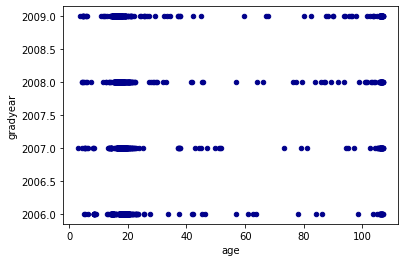

In [ ]:
# 나이에 최소가 3세, 최대가 106세다. 문제가 있다. 졸업년도를 이용해 나이를 보정하자.
data.plot.scatter(x='age', y='gradyear',c='DarkBlue')

In [7]:
age_est = data.groupby('gradyear')['age'].median()
age_est

,age
gradyear,
2006,18.678
2007,17.697
2008,16.739
2009,15.792


In [8]:
age_est = age_est.to_dict()

In [9]:
for idx, row in data.iterrows():
    if row['age'] > 20:
        data.at[idx, 'age']  = age_est[data.loc[idx]['gradyear']]


<Axes: xlabel='age', ylabel='gradyear'>

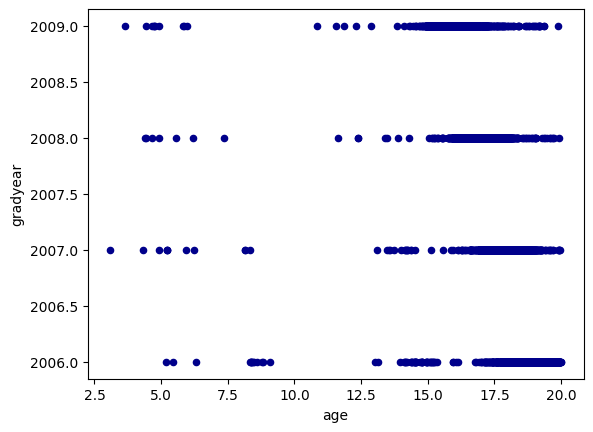

In [10]:
data.plot.scatter(x='age', y='gradyear',c='DarkBlue')

In [11]:
interest = data.iloc[:,4:]

In [12]:
interest.head()

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,2,0,0,0,0,0


In [13]:
interest = (interest - interest.mean())/interest.std()

In [14]:
interest.head()

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,-0.339568,-0.369360,-0.245497,-0.224583,-0.2227,-0.260974,-0.208842,-0.20513,-0.170662,-0.304997,...,-0.048735,-0.37489,-0.49529,-0.317782,-0.200540,-0.185599,-0.302112,-0.270165,-0.224252,-0.177043
1,-0.339568,1.017979,-0.245497,-0.224583,-0.2227,-0.260974,-0.208842,-0.20513,-0.170662,-0.304997,...,-0.048735,1.02708,-0.49529,-0.317782,-0.200540,-0.185599,-0.302112,-0.270165,-0.224252,-0.177043
2,-0.339568,1.017979,-0.245497,-0.224583,-0.2227,-0.260974,-0.208842,-0.20513,-0.170662,-0.304997,...,-0.048735,-0.37489,-0.49529,-0.317782,-0.200540,-0.185599,-0.302112,2.002194,-0.224252,-0.177043
3,-0.339568,-0.369360,-0.245497,-0.224583,-0.2227,-0.260974,-0.208842,-0.20513,-0.170662,-0.304997,...,-0.048735,-0.37489,-0.49529,-0.317782,-0.200540,-0.185599,-0.302112,-0.270165,-0.224252,-0.177043
6,-0.339568,-0.369360,-0.245497,-0.224583,-0.2227,-0.260974,-0.208842,-0.20513,-0.170662,-0.304997,...,-0.048735,2.42905,-0.49529,-0.317782,5.493075,-0.185599,-0.302112,-0.270165,-0.224252,-0.177043


In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 5).fit(interest)
centers = kmeans.cluster_centers_

In [16]:
centers.shape

(5, 36)

In [17]:
center_df = pd.DataFrame(centers, columns = interest.columns.to_list())
center_df.head()


,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,0.368082,0.394069,0.165894,0.207073,0.059618,0.219415,0.165899,0.315083,0.112300,0.839538,...,0.355791,0.567677,0.216333,1.193771,0.214419,0.352654,1.656237,0.944327,1.751035,2.640275
1,0.268642,0.368571,0.245480,0.151180,-0.060949,0.323334,0.505652,0.102280,0.099983,0.089361,...,0.044765,0.778142,0.987304,0.601458,0.729289,0.655245,0.033923,0.089348,0.015782,-0.067055
2,0.150471,-0.011127,0.009887,-0.007475,-0.026006,0.020970,-0.014214,0.012723,0.049780,0.019459,...,-0.004161,-0.101737,-0.030292,0.024607,-0.073569,-0.062268,0.191827,0.279255,0.084375,0.068171
3,-0.101706,-0.103521,-0.062907,-0.068402,-0.155673,-0.083494,-0.114491,-0.040019,-0.027813,-0.078545,...,-0.026758,-0.189387,-0.224447,-0.184959,-0.161653,-0.154856,-0.088610,-0.070590,-0.086949,-0.111746
4,0.681514,0.208518,0.088911,0.762425,4.725656,0.128649,0.019771,0.084435,0.006362,0.528555,...,0.005454,0.027547,0.214416,0.007285,-0.000686,0.049365,-0.096633,-0.014923,-0.095109,-0.112715


In [18]:
cluster_ids = kmeans.fit_predict(interest)

In [19]:
cluster_ids.shape

(24005,)

In [20]:
data.shape

(24005, 40)

In [ ]:
data['cluster'] = cluster_ids

In [ ]:
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster
0,2006,M,18.982,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0,3
2,2006,M,18.335,69,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,2006,F,18.930,72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0
